# Unsupervised Learning: K-Means Clustering

Welcome to **Unsupervised Learning**! Unlike supervised learning, we no longer have "labels" (`y`). We only have features (`X`). 
The algorithm's job is to discover hidden structures, patterns, or groupings within the data entirely on its own.

**K-Means Clustering** is the most famous unsupervised algorithm. It attempts to group data into `K` distinct clusters.

### How K-Means Works (The 3 Steps):
1. **Initialization:** Randomly drop `K` points (called "centroids") into the dataset.
2. **Assignment:** Calculate the distance from every data point to all centroids. Assign each point to the cluster of its closest centroid.
3. **Update:** Move each centroid to the exact geometric center (mean) of all the points currently assigned to it.
*(Repeat steps 2 and 3 until the centroids stop moving!)*


Converged at iteration 5!


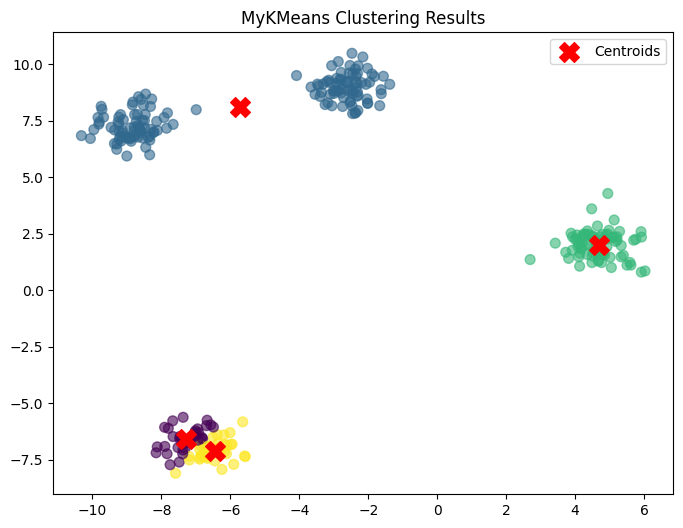

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

class MyKMeans:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        
    def fit(self, X):
        n_samples, n_features = X.shape
        
        # 1. Initialization: randomly pick K points from the dataset as initial centroids
        random_indices = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_indices]
        
        for i in range(self.max_iters):
            # 2. Assignment: create empty clusters
            clusters = [[] for _ in range(self.k)]
            
            # Find closest centroid for each point
            for point_idx, point in enumerate(X):
                # Calculate euclidean distance to all centroids
                distances = [np.linalg.norm(point - centroid) for centroid in self.centroids]
                closest_centroid_idx = np.argmin(distances)
                # Assign point index to the closest cluster
                clusters[closest_centroid_idx].append(point_idx)
                
            # 3. Update: calculate new centroids (mean of points in each cluster)
            prev_centroids = np.copy(self.centroids)
            
            for cluster_idx, point_indices in enumerate(clusters):
                if len(point_indices) == 0:
                    continue # Avoid division by zero if a cluster is empty
                cluster_points = X[point_indices]
                self.centroids[cluster_idx] = np.mean(cluster_points, axis=0)
                
            # Check for convergence (if centroids barely moved, stop early!)
            centroid_shift = np.sum(np.linalg.norm(self.centroids - prev_centroids, axis=1))
            if centroid_shift < self.tol:
                print(f"Converged at iteration {i}!")
                break
                
        # Final assignment to create labels
        self.labels_ = np.zeros(n_samples)
        for cluster_idx, point_indices in enumerate(clusters):
            for point_idx in point_indices:
                self.labels_[point_idx] = cluster_idx

    def predict(self, X):
        predictions = []
        for point in X:
            distances = [np.linalg.norm(point - centroid) for centroid in self.centroids]
            predictions.append(np.argmin(distances))
        return np.array(predictions)

# --- Let's Test MyKMeans! ---
# Create synthetic data with 4 distinct "blobs" (clusters)
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Instantiate and fit
my_kmeans = MyKMeans(k=4)
my_kmeans.fit(X)

# Visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=my_kmeans.labels_, cmap='viridis', s=50, alpha=0.6)
# Plot the final centroids in red
plt.scatter(my_kmeans.centroids[:, 0], my_kmeans.centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("MyKMeans Clustering Results")
plt.legend()
plt.show()


## How do we choose K? (The Elbow Method)
In the real world, you don't know how many clusters exist in the data beforehand.

To find the optimal `K`, we use the **Elbow Method**:
1. Run K-Means for a range of K values (e.g., K=1 to 10).
2. For each K, calculate the **Inertia** (the sum of squared distances from every point to its assigned centroid. Lower is better).
3. Plot the Inertia against K. The point where the sharp drop levels off into a steady slope (looking like an "elbow") is the optimal K.

Let's do this using the professional `sklearn.cluster.KMeans` library!


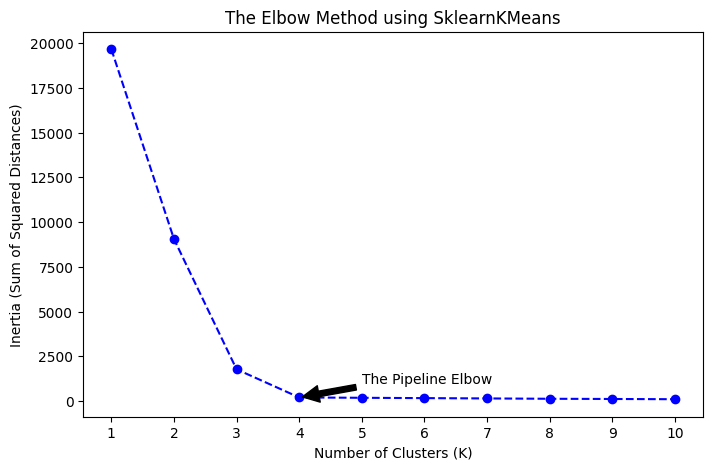

In [4]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(1, 11)

for k in k_values:
    # Set n_init to suppress warnings and ensure stable results
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    # kmeans.inertia_ contains the sum of squared distances
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method using SklearnKMeans')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(k_values)
plt.annotate('The Pipeline Elbow', xy=(4, inertias[3]), xytext=(5, 1000),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

Notice how the massive drops stop at K=4. This correctly tells us there are 4 clusters!